In [ ]:
import math
import time
import csv
from pathlib import Path
import numpy as np
import casadi as ca
import sympy as sp
import matplotlib.pyplot as plt
from k1_acrobot_new import k1_0, k1_1, y, val_lambda, val_delta
from acrobot_inverse_kinematics import inverse_kinematics

nx = 4
nu = 2
DT = 0.00025        # sampling / integrate step (tune)
HORIZON = 8
MU_1 = 1000.0      # certificate parameter (tune)
EPS_G_INV = 1e-6
U_MIN = np.array([-1e20, -1e20])
U_MAX = np.array([1e20, 1e20])

# MPC cost weights
Qy = 1000.0
R_u = 0.0000000
ALPHA = 0.000000025

# Good Params 1: MU_1=1000.0, Qy=1000.0, ALPHA=0.00000005, DT=0.0005
# Good Params 2: MU_1=1000.0, Qy=1000.0, ALPHA=0.00000001, DT=0.0005
# Good Params 3: MU_1=1000.0, Qy=1000.0, ALPHA=0.000000025, DT=0.00025 (best so far)
# Good Params 4: MU_1=1000.0, Qy=1000.0, ALPHA=0.00000001, DT=0.00025

# goal in Target Set
GOAL = np.array([5.8, 1.9])

# solver options
IPOPT_MAX_CPU = 3.0
IPOPT_TOL = 1e-6

# logging
LOG_CSV = "mpc_upgraded_acrobot_fixed_log.csv"

# physical parameters
m1 = 1.0
m2 = 1.0
l1 = 4.0
l2 = 4.0
lc1 = 2.0
lc2 = 2.0
I1 = 0.02
I2 = 0.02
g_grav = 9.81

y0_s, y1_s = sp.symbols('y0 y1')
x0_s, x1_s, x2_s, x3_s = sp.symbols('x0 x1 x2 x3')

# psi(y) and phi(y) from baseline
psi_sym_y = -((4 * (y0_s - 2) - 2 * y1_s**3) ** 2) + 0.8 * y1_s**3 + 10
phi_sym_y = (((y0_s - 2) - 3.8) ** 2 / 1.2**2) + ((y1_s - 1.9) ** 2 / 0.4**2) - 1

psi_func_numpy = sp.lambdify((y0_s, y1_s), psi_sym_y, 'numpy')
phi_func_numpy = sp.lambdify((y0_s, y1_s), phi_sym_y, 'numpy')

y0=0.000, y1=-1.600
y0=2.000, y1=0.700
y0=3.000, y1=1.000
Found 3 safe initial states
Running corrected MPC-only closed-loop (no fallback). Logging to mpc_upgraded_acrobot_fixed_log.csv

Trial 0, initial = [-2.94023473  2.73887681  0.          0.        ]
Step 0

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Step 31
Step 32
Step 33
Step 34
Step 35
Step 36
Step 37
Step 38
Step 39
Step 40
Step 41
Step 42
Step 43
Step 44
Step 45

In [ ]:
# Build CasADi SX dynamics for Acrobot

x_c = ca.SX.sym('x', nx)
u_c = ca.SX.sym('u', nu)

# states
q1 = x_c[0]; q2 = x_c[1]; q1dot = x_c[2]; q2dot = x_c[3]

# inertia
M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * ca.cos(q2))
M12 = m2 * (lc2**2 + l1 * lc2 * ca.cos(q2)) + I2
M21 = M12
M22 = m2 * lc2**2 + I2
M_mat = ca.vertcat(ca.horzcat(M11, M12), ca.horzcat(M21, M22))

# Coriolis-like
C11 = -m2 * l1 * lc2 * ca.sin(q2) * q2dot
C12 = -m2 * l1 * lc2 * ca.sin(q2) * (q1dot + q2dot)
C21 = m2 * l1 * lc2 * ca.sin(q2) * q1dot
C22 = 0
C_mat = ca.vertcat(ca.horzcat(C11, C12), ca.horzcat(C21, C22))

# gravity vector
G1 = (m1 * g_grav * lc1 + m2 * g_grav * l1) * ca.cos(q1) + m2 * g_grav * lc2 * ca.cos(q1 + q2)
G2 = m2 * g_grav * lc2 * ca.cos(q1 + q2)
G_vec = ca.vertcat(G1, G2)

# continuous dynamics f(x) and input matrix g(x)
qdot_vec = ca.vertcat(q1dot, q2dot)
M_inv = ca.inv(M_mat)
f_lower = -ca.mtimes(M_inv, (ca.mtimes(C_mat, qdot_vec) + G_vec))
f_cas = ca.vertcat(q1dot, q2dot, f_lower[0], f_lower[1])

g_cas = ca.vertcat(ca.SX.zeros(2,2), M_inv)  # 4x2

# output map h(x): end-effector
h_x_c = ca.vertcat(l1 * ca.cos(q1) + l2 * ca.cos(q1 + q2),
                   l1 * ca.sin(q1) + l2 * ca.sin(q1 + q2))

def sympy_to_casadi_SX(sym_expr, sym_vars=(y0_s, y1_s), cas_vars=None):
    if cas_vars is None:
        cas_vars = [ca.SX.sym('y0'), ca.SX.sym('y1')]
    try:
        poly = sp.Poly(sp.expand(sym_expr), *sym_vars)
        expr_val = ca.SX(0)
        for mon_exps, coeff in poly.as_dict().items():
            coeff_f = float(sp.N(coeff))
            term = ca.SX(coeff_f)
            for idx, e in enumerate(mon_exps):
                if e != 0:
                    term = term * (cas_vars[idx] ** int(e))
            expr_val = expr_val + term
        return expr_val
    except Exception:
        # fallback: safe string replace with casadi functions
        s = str(sp.expand(sym_expr))
        y0_c = cas_vars[0]; y1_c = cas_vars[1]
        allowed = {'sin': ca.sin, 'cos': ca.cos, 'tan': ca.tan, 'sqrt': ca.sqrt,
                   'Abs': ca.fabs, 'pi': ca.pi, 'y0': y0_c, 'y1': y1_c, 'pow': ca.power}
        expr_c = eval(s, {"__builtins__": {}}, allowed)
        return ca.simplify(expr_c)

# psi in y-space
y0_cas = ca.SX.sym('y0'); y1_cas = ca.SX.sym('y1')
psi_cas_in_y = sympy_to_casadi_SX(psi_sym_y, (y0_s, y1_s), cas_vars=[y0_cas, y1_cas])

# k1 in y-space (from your imported sympy k1_0,k1_1)
k1_0_cas_in_y = sympy_to_casadi_SX(k1_0, (y0_s, y1_s), cas_vars=[y0_cas, y1_cas])
k1_1_cas_in_y = sympy_to_casadi_SX(k1_1, (y0_s, y1_s), cas_vars=[y0_cas, y1_cas])
k1_cas_in_y = ca.vertcat(k1_0_cas_in_y, k1_1_cas_in_y)

# Dk1 and Dy_psi in y-space
Dk1_in_y = ca.jacobian(k1_cas_in_y, ca.vertcat(y0_cas, y1_cas))
dpsi_dy_in_y = ca.jacobian(psi_cas_in_y, ca.vertcat(y0_cas, y1_cas)).T

# substitute y -> h(x)
k1_at_x_cas = ca.substitute([k1_cas_in_y], [y0_cas, y1_cas], [h_x_c[0], h_x_c[1]])[0]
Dk1_at_x_cas = ca.substitute([Dk1_in_y], [y0_cas, y1_cas], [h_x_c[0], h_x_c[1]])[0]
psi_at_x_cas = ca.substitute([psi_cas_in_y], [y0_cas, y1_cas], [h_x_c[0], h_x_c[1]])[0]
Dy_psi_at_x_cas = ca.substitute([dpsi_dy_in_y], [y0_cas, y1_cas], [h_x_c[0], h_x_c[1]])[0]

# Lfh and derivatives for backstepping
Jh = ca.jacobian(h_x_c, x_c)  # 2x4
Lfh_cas = ca.mtimes(Jh, f_cas)  # 2x1

Lfh_jacobian = ca.jacobian(Lfh_cas, x_c)  # 2x4
F_cas = ca.mtimes(Lfh_jacobian, f_cas)  # 2x1
G_back = ca.mtimes(Lfh_jacobian, g_cas)  # 2x2

# Backstepping controller k_full
eps_reg = EPS_G_INV
GtG = ca.mtimes(G_back.T, G_back)
GtG_reg = GtG + eps_reg * ca.SX.eye(2)
GtG_reg_inv = ca.inv(GtG_reg)
Ginv_back = ca.mtimes(GtG_reg_inv, G_back.T)

rhs_k = -F_cas + MU_1 * Dy_psi_at_x_cas + ca.mtimes(Dk1_at_x_cas, Lfh_cas) + (val_lambda / 2.0) * (Lfh_cas - k1_at_x_cas)
k_full_cas = ca.mtimes(Ginv_back, rhs_k)

# Terminal certificate Psi(x)
Psi_cas = psi_at_x_cas - (1.0 / (2.0 * MU_1)) * ca.dot(Lfh_cas - k1_at_x_cas, Lfh_cas - k1_at_x_cas)

# Expose CasADi functions for diagnostics / evaluation
k_full_fun = ca.Function('k_full_fun', [x_c], [k_full_cas])
k1_fun = ca.Function('k1_fun', [x_c], [k1_at_x_cas])
Psi_fun_cas = ca.Function('Psi_fun', [x_c], [Psi_cas])
psi_fun_cas = ca.Function('psi_fun', [x_c], [psi_at_x_cas])
f_disc = None  # will be built next (CasADi RK4 with dt arg)

In [ ]:
# CasADi RK4 integrator
def casadi_rk4_step_acrobot(x, u, dt):
    # dt may be SX or float; implement RK4 using the same f_total_sym pattern as earlier
    def f_total_sym(xv, uv):
        q1v = xv[0]; q2v = xv[1]; q1dv = xv[2]; q2dv = xv[3]
        M11v = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * ca.cos(q2v))
        M12v = m2 * (lc2**2 + l1 * lc2 * ca.cos(q2v)) + I2
        M21v = M12v
        M22v = m2 * lc2**2 + I2
        Mv = ca.vertcat(ca.horzcat(M11v, M12v), ca.horzcat(M21v, M22v))
        C11v = -m2 * l1 * lc2 * ca.sin(q2v) * q2dv
        C12v = -m2 * l1 * lc2 * ca.sin(q2v) * (q1dv + q2dv)
        C21v = m2 * l1 * lc2 * ca.sin(q2v) * q1dv
        C22v = 0
        Cv = ca.vertcat(ca.horzcat(C11v, C12v), ca.horzcat(C21v, C22v))
        G1v = (m1 * g_grav * lc1 + m2 * g_grav * l1) * ca.cos(q1v) + m2 * g_grav * lc2 * ca.cos(q1v + q2v)
        G2v = m2 * g_grav * lc2 * ca.cos(q1v + q2v)
        Gv = ca.vertcat(G1v, G2v)
        Minv_v = ca.inv(Mv)
        qdot_v = ca.vertcat(q1dv, q2dv)
        f_lower_v = -ca.mtimes(Minv_v, (ca.mtimes(Cv, qdot_v) + Gv))
        f0 = ca.vertcat(q1dv, q2dv, f_lower_v[0], f_lower_v[1])
        gv = ca.vertcat(ca.SX.zeros(2,2), Minv_v)
        return f0 + ca.mtimes(gv, uv)

    f1 = f_total_sym(x, u)
    x2 = x + 0.5 * dt * f1
    f2 = f_total_sym(x2, u)
    x3 = x + 0.5 * dt * f2
    f3 = f_total_sym(x3, u)
    x4 = x + dt * f3
    f4 = f_total_sym(x4, u)
    return x + (dt/6.0) * (f1 + 2*f2 + 2*f3 + f4)

xnext_cas = casadi_rk4_step_acrobot(x_c, u_c, DT)
f_disc = ca.Function('f_disc', [x_c, u_c], [xnext_cas], ['x', 'u'], ['xnext'])

def build_mpc_solver(N):
    X = ca.SX.sym('X', nx, N)
    U = ca.SX.sym('U', nu, N)
    P = ca.SX.sym('P', nx)
    opt_vars = ca.vertcat(ca.reshape(X, -1, 1), ca.reshape(U, -1, 1))

    g_list = []
    obj = ca.SX(0)

    for k in range(N):
        if k == 0:
            xk = P
        else:
            xk = X[:, k]
        uk = U[:, k]

        # dynamics equality: X[:,k] == f_disc(xk, uk)
        xkpred = f_disc(xk, uk)
        g_list.append(X[:, k] - xkpred)   # nx entries

        # stage psi at X[:,k]
        psi_stage = ca.substitute([psi_at_x_cas], [x_c], [X[:, k]])[0]
        g_list.append(psi_stage)

        # end-effector at predicted state X[:,k] for tracking cost
        # build y_k from q1,q2 entries of X[:,k]
        q1_k = X[0, k]; q2_k = X[1, k]
        y_k = ca.vertcat(
            l1 * ca.cos(q1_k) + l2 * ca.cos(q1_k + q2_k),
            l1 * ca.sin(q1_k) + l2 * ca.sin(q1_k + q2_k)
        )

        # stage costs
        obj = obj + Qy * ca.dot(y_k - ca.DM(GOAL), y_k - ca.DM(GOAL))
        obj = obj + R_u * ca.dot(uk, uk)

        # bias toward backstepping controller at stage k:
        k_full_at_xk = ca.substitute([k_full_cas], [x_c], [xk])[0]
        diff_u = uk - k_full_at_xk
        obj = obj + ALPHA * ca.dot(diff_u, diff_u)

    # terminal Psi on full-state X[:,N-1]
    xN = X[:, N-1]
    Psi_end = ca.substitute([Psi_cas], [x_c], [xN])[0]
    g_list.append(Psi_end)

    g_all = ca.vertcat(*g_list)

    nlp = {'x': opt_vars, 'f': obj, 'g': g_all, 'p': P}
    opts = {
        'ipopt': {
            'print_level': 0,
            'max_cpu_time': IPOPT_MAX_CPU,
            'tol': IPOPT_TOL,
            'acceptable_tol': 1e-4,
            'constr_viol_tol': 1e-6,
            'acceptable_constr_viol_tol': 1e-4
        },
        'print_time': False
    }
    solver = ca.nlpsol('solver', 'ipopt', nlp, opts)

    nxN = nx * N
    nconstr = int(g_all.numel())
    return solver, nxN, nconstr

solver, nxN, nconstr = build_mpc_solver(HORIZON)

In [ ]:
def default_bounds_and_guesses(N):
    nxN = nx * N
    nuN = nu * N
    nvars = nxN + nuN
    guess = np.zeros(nvars)
    lbx = -1e20 * np.ones(nvars)
    ubx =  1e20 * np.ones(nvars)
    # choose reasonable control bounds (tune as needed)
    for k in range(N):
        idx = nxN + k * nu
        lbx[idx:idx+nu] = U_MIN
        ubx[idx:idx+nu] = U_MAX
    return guess, lbx, ubx

x0_guess_template, lbx, ubx = default_bounds_and_guesses(HORIZON)

_prev_w_opt = None
use_warmstart = False

def make_initial_guess(x0, N, prev_w_opt=None, use_warmstart=False):
    nxN = nx * N
    nuN = nu * N
    nvars = nxN + nuN
    if use_warmstart and (prev_w_opt is not None) and prev_w_opt.size == nvars:
        return prev_w_opt.copy()
    guess = np.zeros(nvars)
    for k in range(N):
        idx = k * nx
        guess[idx:idx+nx] = x0
    return guess

k1_func_numpy = sp.lambdify((y0_s, y1_s), sp.Matrix([k1_0, k1_1]), 'numpy')

def eval_k1_numpy_from_y(yvec):
    v = k1_func_numpy(yvec[0], yvec[1])
    return np.array(v, dtype=float).reshape((2,))

def compute_h_numpy(x):
    q1v = x[0]; q2v = x[1]
    y0 = l1 * np.cos(q1v) + l2 * np.cos(q1v + q2v)
    y1 = l1 * np.sin(q1v) + l2 * np.sin(q1v + q2v)
    return np.array([y0, y1])

def compute_Lfh_numpy(x):
    q1v, q2v, q1dv, q2dv = x
    M11v = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * math.cos(q2v))
    M12v = m2 * (lc2**2 + l1 * lc2 * math.cos(q2v)) + I2
    M21v = M12v
    M22v = m2 * lc2**2 + I2
    Mv = np.array([[M11v, M12v], [M21v, M22v]])
    C11v = -m2 * l1 * lc2 * math.sin(q2v) * q2dv
    C12v = -m2 * l1 * lc2 * math.sin(q2v) * (q1dv + q2dv)
    C21v = m2 * l1 * lc2 * math.sin(q2v) * q1dv
    Cv = np.array([[C11v, C12v], [C21v, 0.0]])
    G1v = (m1 * g_grav * lc1 + m2 * g_grav * l1) * math.cos(q1v) + m2 * g_grav * lc2 * math.cos(q1v + q2v)
    G2v = m2 * g_grav * lc2 * math.cos(q1v + q2v)
    Gv = np.array([G1v, G2v])
    Minv = np.linalg.inv(np.array([[M11v, M12v], [M21v, M22v]]))
    f_lower_v = -Minv.dot(Cv.dot(np.array([q1dv, q2dv])) + Gv)
    f_vec = np.array([q1dv, q2dv, float(f_lower_v[0]), float(f_lower_v[1])])
    # Jacobian of h (2x4)
    Jh = np.zeros((2,4))
    Jh[0,0] = -l1 * math.sin(q1v) - l2 * math.sin(q1v + q2v)
    Jh[1,0] =  l1 * math.cos(q1v) + l2 * math.cos(q1v + q2v)
    Jh[0,1] = -l2 * math.sin(q1v + q2v)
    Jh[1,1] =  l2 * math.cos(q1v + q2v)
    Lfh = Jh.dot(f_vec)
    return Lfh.reshape((2,))

def compute_Psi_numeric_from_numpy(x):
    # Use the CasADi Psi function to ensure exact consistency
    return float(Psi_fun_cas(ca.DM(x)).full().item())

# Numpy RK4 integrator for plant simulation
def rk4_step_numpy(xvec, uvec, dt=DT):
    def f_cont_num(xv, uv):
        q1v, q2v, q1dv, q2dv = xv
        M11v = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * math.cos(q2v))
        M12v = m2 * (lc2**2 + l1 * lc2 * math.cos(q2v)) + I2
        M21v = M12v
        M22v = m2 * lc2**2 + I2
        Mv = np.array([[M11v, M12v], [M21v, M22v]])
        C11v = -m2 * l1 * lc2 * math.sin(q2v) * q2dv
        C12v = -m2 * l1 * lc2 * math.sin(q2v) * (q1dv + q2dv)
        C21v = m2 * l1 * lc2 * math.sin(q2v) * q1dv
        Cv = np.array([[C11v, C12v], [C21v, 0.0]])
        G1v = (m1 * g_grav * lc1 + m2 * g_grav * l1) * math.cos(q1v) + m2 * g_grav * lc2 * math.cos(q1v + q2v)
        G2v = m2 * g_grav * lc2 * math.cos(q1v + q2v)
        Gv = np.array([G1v, G2v])
        Minv = np.linalg.inv(Mv)
        f_lower_v = -Minv.dot(Cv.dot(np.array([q1dv, q2dv])) + Gv)
        fvec = np.array([q1dv, q2dv, float(f_lower_v[0]), float(f_lower_v[1])])
        gmat = np.vstack((np.zeros((2,2)), Minv))
        return fvec + gmat.dot(uv)

    k1 = f_cont_num(xvec, uvec)
    k2 = f_cont_num(xvec + 0.5*dt*k1, uvec)
    k3 = f_cont_num(xvec + 0.5*dt*k2, uvec)
    k4 = f_cont_num(xvec + dt*k3, uvec)
    return xvec + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

In [ ]:
objs = []
def solve_mpc_once(x0, N=HORIZON):
    global _prev_w_opt
    p = x0.copy()
    x0_guess_local = make_initial_guess(x0, N, _prev_w_opt, use_warmstart)

    # constraints count
    total_eq = N * nx
    total_ineq_stage = N
    total_ineq_final = 1
    total_constraints = total_eq + total_ineq_stage + total_ineq_final

    lbg = np.zeros(total_constraints)
    ubg =  1e20 * np.ones(total_constraints)

    # fill lbg/ubg by following g_list ordering
    idx = 0
    for k in range(N):
        # dynamics equality (nx)
        for _ in range(nx):
            lbg[idx] = 0.0; ubg[idx] = 0.0
            idx += 1
        # midpoint psi (if used) -> inequality >= 0

        # stage psi -> inequality >= 0
        lbg[idx] = 0; ubg[idx] = 1e20
        idx += 1

    # final Psi -> inequality >= 0
    lbg[idx] = 0; ubg[idx] = 1e20

    try:
        tic = time.time()
        sol = solver(x0=x0_guess_local, lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg, p=p)
        elapsed = time.time() - tic
        w_opt = np.array(sol['x']).flatten()
        _prev_w_opt = w_opt.copy()

        # first control u0
        u0 = w_opt[nxN : nxN + nu].copy()

        X_flat = w_opt[0:nxN]
        psi_pred_vals = []
        idx_w = 0
        for k in range(N):
            xk_pred = X_flat[k*nx:(k+1)*nx]
            y_pred = np.array([l1 * math.cos(xk_pred[0]) + l2 * math.cos(xk_pred[0] + xk_pred[1]),
                               l1 * math.sin(xk_pred[0]) + l2 * math.sin(xk_pred[0] + xk_pred[1])])
            psi_k = float(psi_func_numpy(y_pred[0], y_pred[1]))
            psi_pred_vals.append(psi_k)
        min_psi_pred = float(np.min(psi_pred_vals))

        xN = X_flat[(N-1)*nx:(N)*nx]
        psi_terminal = compute_Psi_numeric_from_numpy(xN)

        obj_val = float(sol['f'])
        # print(f"obj={obj_val:.6f}")
        objs.append(obj_val)
        stats = solver.stats()
        return True, u0, {'xN': xN.copy(), 'min_psi_pred': min_psi_pred, 'psi_terminal': psi_terminal, 'obj': obj_val, 'solve_time': elapsed, 'stats': stats, 'raw_sol': sol}
    except Exception as e:
        return False, None, {'error': str(e)}

def run_mpc_closed_loop(initial_state, horizon=HORIZON, max_steps=200, log_file=None):
    x = initial_state.copy()
    traj = [x.copy()]
    used = []
    reached = False

    if log_file is not None:
        csv_f = open(log_file, 'w', newline='')
        csv_writer = csv.writer(csv_f)
        csv_writer.writerow(['step','used','psi_current','min_psi_pred','psi_terminal','obj','solve_time','reached','note'])
    else:
        csv_f = None; csv_writer = None

    for t in range(max_steps):
        print(f"Step {t}")
        ycur = compute_h_numpy(x)
        psi_curr = float(psi_func_numpy(ycur[0], ycur[1]))
        ok, u0, info = solve_mpc_once(x, N=horizon)

        if not ok:
            note = f"MPC infeasible or failed at step {t}: {info.get('error')}"
            print(note)
            if csv_writer:
                csv_writer.writerow([t, 'MPC_FAIL', psi_curr, None, None, None, None, False, note])
            break

        if _prev_w_opt is not None:
            w = _prev_w_opt
            X_flat = w[0:nxN]
            x1_pred = X_flat[0:nx].copy()
            y1p = np.array([l1 * math.cos(x1_pred[0]) + l2 * math.cos(x1_pred[0] + x1_pred[1]),
                            l1 * math.sin(x1_pred[0]) + l2 * math.sin(x1_pred[0] + x1_pred[1])])
            psi_pred_x1 = float(psi_func_numpy(y1p[0], y1p[1]))

        u_apply = np.minimum(np.maximum(np.array(u0).reshape((2,)), U_MIN), U_MAX)
        used.append('MPC')

        # apply to plant
        x_next = rk4_step_numpy(x, u_apply, DT)
        traj.append(x_next.copy())

        # compute mins
        min_psi_pred = info.get('min_psi_pred', None)
        psi_terminal = info.get('psi_terminal', None)
        obj_val = info.get('obj', None)
        solve_time = info.get('solve_time', None)

        # compute actual psi after applying control
        y_after = compute_h_numpy(x_next)
        psi_after = float(psi_func_numpy(y_after[0], y_after[1]))

        if csv_writer:
            csv_writer.writerow([t, 'MPC', psi_curr, min_psi_pred, psi_terminal, obj_val, solve_time, False, ''])
        else:
            print(f"step {t}: psi_curr={psi_curr:.6e}, psi_pred_next={psi_pred_x1 if _prev_w_opt is not None else None:.6e}, psi_after={psi_after:.6e}, min_psi_pred={min_psi_pred:.6e}, psi_term={psi_terminal:.6e}, obj={obj_val:.6f}, solved_in={solve_time:.3f}s")

        # check phi (target) using end-effector
        ynow = compute_h_numpy(x_next)
        phi_val = float(phi_func_numpy(ynow[0], ynow[1]))
        reached = True if (phi_val < 0) else False

        if reached:
            print(f"Reached target at step {t}")
            break

        x = x_next

    if csv_f:
        csv_f.close()
    return {'traj': np.array(traj), 'used': used, 'reached': reached}

In [ ]:
if __name__ == "__main__":
    # build some safe initials via IK
    initials = []
    np.random.seed(7)
    ys = np.random.random((2, 60)) * 2 * np.sqrt(l1**2 + l2**2) - np.sqrt(l1**2 + l2**2)
    desired_points = [
        (0, -1.6),        
        (2, 0.7),
        (3, 1)
    ]
    ys = np.array(desired_points).T
    for i in range(ys.shape[1]):
        try:
            (q1_1, q2_1), _ = inverse_kinematics(ys[0, i], ys[1, i], l1, l2)
        except Exception:
            continue
        x0 = np.array([q1_1, q2_1, 0.0, 0.0])
        # ys[0,i], ys[1,i] = compute_h_numpy(x0)
        # print(f"y0={ys[0,i]:.3f}, y1={ys[1,i]:.3f}")
        if (psi_func_numpy(ys[0,i], ys[1,i]) >= 0) and (phi_func_numpy(ys[0,i], ys[1,i]) > 0):
            initials.append(x0)
            print(f"y0={ys[0,i]:.3f}, y1={ys[1,i]:.3f}")

    initials = np.array(initials)
    print(f"Found {len(initials)} safe initial states")

    all_results = []
    print("Running corrected MPC-only closed-loop (no fallback). Logging to", LOG_CSV)
    for i, init in enumerate(initials[:10]):   # test a subset
        print(f"\nTrial {i}, initial = {init}")
        objs = []
        res = run_mpc_closed_loop(init, horizon=HORIZON, max_steps=2000, log_file=f"run_{i}_" + LOG_CSV)
        all_results.append(res)        
        print("Result:", "reached" if res['reached'] else "not reached", "steps:", res['traj'].shape[0])

    xs = np.linspace(-3, 6, 200)
    ys = np.linspace(-2.5, 3, 200)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.zeros_like(XX)
    PH = np.zeros_like(XX)
    for ii in range(XX.shape[0]):
        for jj in range(XX.shape[1]):
            ZZ[ii,jj] = float(psi_func_numpy(XX[ii,jj], YY[ii,jj]))
            PH[ii,jj] = float(phi_func_numpy(XX[ii,jj], YY[ii,jj]))

(2, 200, 200) z


C:\Users\nisha\AppData\Local\Temp\ipykernel_14580\439753524.py:103: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(
C:\Users\nisha\AppData\Local\Temp\ipykernel_14580\439753524.py:116: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


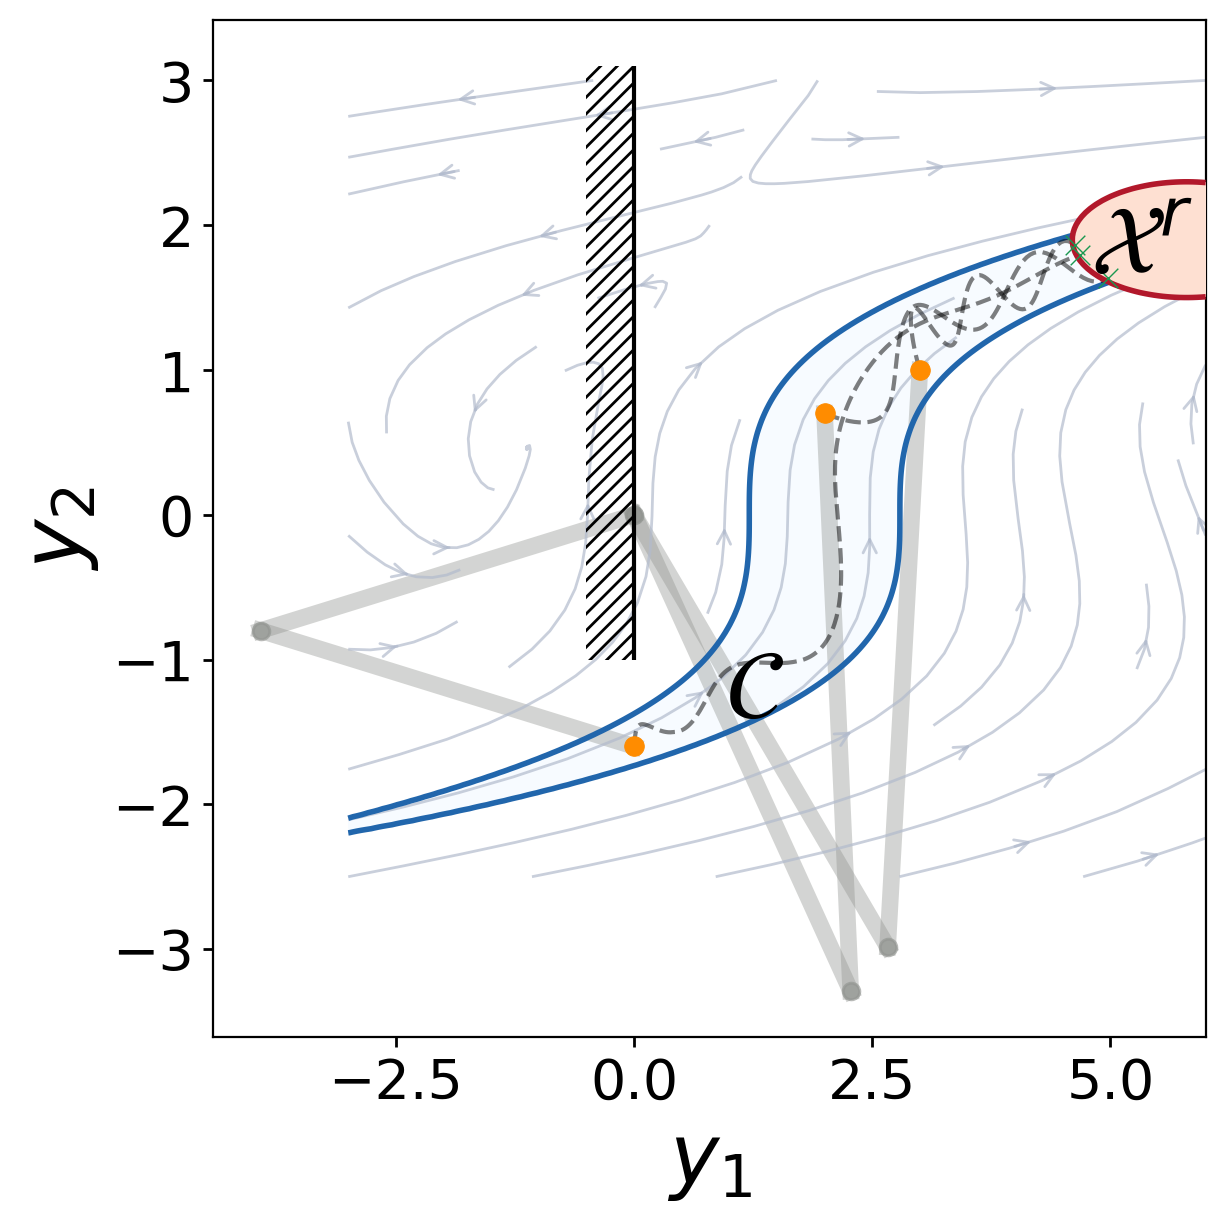

In [7]:
from functional import BetterColor, simulate
from matplotlib.patches import Rectangle
px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(610 * px, 600 * px), layout="constrained")
fig.set_dpi(200)


# vector field of the single-integrator system with k1 controller
k1 = sp.Matrix([k1_0, k1_1])
k1f = sp.lambdify(y, k1, "numpy")
Z = k1f(XX, YY).squeeze()
print(Z.shape, "z")
ax.streamplot(
    XX,
    YY,
    Z[0],
    Z[1],
    density=0.5,
    # color="#404040",  # medium gray tone
    # color="#2F4F4F",
    color=BetterColor.gray0(0.7),
    linewidth=1,
    arrowstyle="->",
    arrowsize=1.2,
)

ax.contourf(
    XX,
    YY,
    ZZ,
    levels=[0, +np.inf],
    colors=["#e6f2ff"],  # very light blue
    # hatches=["..."],  # dotted pattern
    alpha=0.3,
    zorder=1,
)


ax.contour(
    XX,
    YY,
    ZZ,
    levels=[0],
    colors=["#2166ac"],  # academic blue
    linewidths=2,
    zorder=2,
)


ax.contourf(
    XX,
    YY,
    PH,
    levels=[-np.inf, 0],
    colors=["#fee0d2"],  # light coral
    # hatches=["////"],  # diagonal line pattern
    alpha=1,
    zorder=100,
)
ax.contour(
    XX,
    YY,
    PH,
    levels=[0],
    colors=["#b2182b"],  # dark red
    linewidths=2,
    zorder=101,
)

line_style = {
    # "color": "#404040",  # use academic gray instead of pure black
    "color": "#2166ac",
    "linestyle": "-",  # use solid line instead of dash-dot
    "alpha": 0.2,
    "linewidth": 0.5,
    "solid_capstyle": "round",
}


# plot each output trajectory
for r in all_results:
    tr = r['traj']  
    Y = np.array([compute_h_numpy(xi) for xi in tr])
    # trajectory
    plt.plot(
        Y[:, 0],
        Y[:, 1],
        # **line_style,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        zorder=5,
        # "red",
        # linewidth=1.0,
        # alpha=0.4,
        # zorder=2,
    )
    # start point
    # plt.scatter(
    #     this_traj_y[0, 0], this_traj_y[0, 1], s=2, c="black", alpha=0.3, zorder=3
    # )
    plt.scatter(
        Y[0, 0],
        Y[0, 1],
        s=50,
        # c="#d73027",  # IEEE red
        c=BetterColor.orange3(),
        # marker="^",  # triangle
        # edgecolor="w",  # white edge
        linewidth=0.3,
        zorder=20,
    )
    # end point
    # plt.scatter(this_traj_y[-1, 0], this_traj_y[-1, 1], s=2.5, c="red", zorder=3)
    plt.scatter(
        Y[-1, 0],
        Y[-1, 1],
        s=50,
        linewidth=0.5,
        # c="#313695",  # dark blue
        # c="#8B008B",
        # c="#4daf4a",
        c=BetterColor.green0(),
        # edgecolors="#984ea3",
        # marker="o",  # circle
        # marker=(5, 1, 0),
        marker="x",
        # edgecolor="#ffffbf",  # light yellow edge
        # linewidth=0.4,
        zorder=200,
    )

# for each trajectory, plot the initial motion and final motion
for r in all_results:
    tr = r['traj']
    this_traj_x = tr
    # plot the initial motion
    q1, q2 = this_traj_x[0, 0], this_traj_x[0, 1]
    x1, y1 = l1* np.cos(q1), l1* np.sin(q1)
    x2, y2 = x1 + l2 * np.cos(q1 + q2), y1 + l2 * np.sin(q1 + q2)

    ax.plot(
        [0, x1],
        [0, y1],
        "o-",
        alpha=0.4,
        lw=6,
        # color="blue",
        # color="gray",
        color=BetterColor.gray2(),
        zorder=1,
    )  # First link

    ax.plot(
        [x1, x2],
        [y1, y2],
        "o-",
        # alpha=alpha_value[i // interval],
        alpha=0.4,
        lw=6,
        # color="red",
        # color="gray",
        color=BetterColor.gray2(),
        zorder=1,
    )  # Second link


width_hatch = 0.5
wall_back = ax.vlines(-width_hatch + width_hatch, -1, 3.1, colors="black")
height_hatch = 4.1
xy_hatch = (-width_hatch, -1)
wall_hatch = Rectangle(
    xy_hatch,
    width_hatch,  # width
    height_hatch,  # height
    facecolor="None",
    linestyle="None",
    hatch="////",
    zorder=1000,
)
ax.add_patch(wall_hatch)

this_fontsize = 35

ax.text(0.95, -1.4, "$\mathcal{C}$", zorder=100, fontsize=this_fontsize)
ax.text(4.8, 1.67, "$\mathcal{X}^r$", zorder=1000, fontsize=this_fontsize)

ax.xaxis.set_tick_params(labelsize=20, width=1)
ax.yaxis.set_tick_params(labelsize=20, width=1)
plt.xlabel("$y_1$", fontsize=this_fontsize - 5)
plt.ylabel("$y_2$", fontsize=this_fontsize - 5)
plt.show()

In [3]:

#         # # plot trajectories
#         # plt.figure(figsize=(8,6))
#         # for r in all_results:
#         #     tr = r['traj']
#         #     plt.plot(tr[:,0], tr[:,1], '-o', markersize=3)
#         #     # start point
#         #     plt.plot(tr[0,0], tr[0,1],
#         #             marker='s', markersize=2,
#         #             color='green', label=None)

#         #     # end point
#         #     plt.plot(tr[-1,0], tr[-1,1],
#         #             marker='*', markersize=2,
#         #             color='red', label=None)        
#         # plot psi=0 and phi=0 contours
#         # xs = np.linspace(-2.5, 2.5, 250)
#         # ys = np.linspace(-2.5, 2.5, 250)
#         # XX, YY = np.meshgrid(xs, ys)
#         # ZZ = np.zeros_like(XX)
#         # PH = np.zeros_like(XX)
#         # PH_new = np.zeros_like(XX)
#         # for ii in range(XX.shape[0]):
#         #     for jj in range(XX.shape[1]):
#         #         ZZ[ii,jj] = float(psi_func_numpy(XX[ii,jj], YY[ii,jj]))
#         #         PH[ii,jj] = float(phi_func_numpy(XX[ii,jj], YY[ii,jj]))
                

#         # Psi_vals = np.zeros_like(XX)

#         # for ii in range(XX.shape[0]):
#         #     x_batch = XX[ii, :]
#         #     y_batch = YY[ii, :]

#         #     # Build full 4×N state input
#         #     full_state = np.vstack([
#         #         x_batch,                # x0
#         #         y_batch,                # x1
#         #         np.zeros_like(x_batch), # theta = 0
#         #         np.zeros_like(x_batch)  # v = 0
#         #     ])

#         #     Psi_vals[ii, :] = np.array(Psi_fun_cas(full_state)).flatten()

#         # plt.contour(XX, YY, Psi_vals, levels=[0.0], colors='blue', linestyles='-.', linewidths=1.2)                                 
#         # plt.contour(XX, YY, ZZ, levels=[0.0], colors='k', linewidths=1.2)
#         # plt.contour(XX, YY, PH, levels=[0.0], colors='r', linestyles='--')
#         # plt.title("Function contours")
#         # plt.xlabel('x'); plt.ylabel('y'); plt.axis('equal'); plt.grid(True)
#         # plt.show()
# from functional import BetterColor, simulate
# px = 1 / plt.rcParams["figure.dpi"]
# fig, ax = plt.subplots(figsize=(610 * px, 600 * px), layout="constrained")
# fig.set_dpi(200)

            

#     # vector field of the single-integrator system with k1 controller
# k1 = sp.Matrix([k1_0, k1_1])
# k1f = sp.lambdify(y, k1, "numpy")
# Z = k1f(XX, YY).squeeze()
# print(Z.shape, "z")
# ax.streamplot(
#         XX,
#         YY,
#         Z[0],
#         Z[1],
#         density=0.5,
#         # color="#404040",  # medium gray tone
#         # color="#2F4F4F",
#         color=BetterColor.gray0(0.7),
#         linewidth=1,
#         arrowstyle="->",
#         arrowsize=1.2,
#     )

# ax.contourf(
#         XX,
#         YY,
#         ZZ,
#         levels=[0, +np.inf],
#         colors=["#e6f2ff"],  # very light blue
#         # hatches=["..."],  # dot pattern
#         alpha=0.3,
#         zorder=1,
#     )

# ax.contour(
#         XX,
#         YY,
#         ZZ,
#         levels=[0],
#         colors=["#2166ac"],  # academic blue
#         linewidths=2,
#         zorder=2,
#     )

# ax.contourf(
#         XX,
#         YY,
#         PH,
#         levels=[-np.inf, 0],
#         colors=["#fee0d2"],  # light coral
#         # hatches=["////"],  # diagonal line pattern
#         alpha=1,
#         zorder=100,
#     )
# ax.contour(
#         XX,
#         YY,
#         PH,
#         levels=[0],
#         colors=["#b2182b"],  # dark red
#         linewidths=2,
#         zorder=101,
#     )

# line_style = {
#         # "color": "#404040",  # use academic gray instead of pure black
#         "color": "#2166ac",
#         "linestyle": "-",  # use solid line instead of dash-dot line
#         "alpha": 0.2,
#         "linewidth": 0.5,
#         "solid_capstyle": "round",
#     }

#     # plot each output trajectory
#     # for i in range(len(traj_y)):
#     #     this_traj_y = traj_y[i]
# for r in all_results:
#             tr = r['traj']  
#             Y = np.array([compute_h_numpy(xi) for xi in tr])  
#             # trajectory
#             plt.plot(
#                 Y[:, 0],
#                 Y[:, 1],
#                 # **line_style,
#                 color="black",
#                 linestyle="--",
#                 linewidth=1.5,
#                 alpha=0.5,
#                 zorder=5,
#                 # "red",
#                 # linewidth=1.0,
#                 # alpha=0.4,
#                 # zorder=2,
#             )
#             # start point
#             # plt.scatter(
#             #     this_traj_y[0, 0], this_traj_y[0, 1], s=2, c="black", alpha=0.3, zorder=3
#             # )
#             plt.scatter(
#                 Y[0, 0],
#                 Y[0, 1],
#                 s=50,
#                 # c="#d73027",  # IEEE red
#                 c=BetterColor.orange3(),
#                 # marker="^",  # triangle
#                 # edgecolor="w",  # white edge
#                 linewidth=0.3,
#                 zorder=20,
#             )
#             # end point
#             # plt.scatter(this_traj_y[-1, 0], this_traj_y[-1, 1], s=2.5, c="red", zorder=3)
#             plt.scatter(
#                 Y[-1, 0],
#                 Y[-1, 1],
#                 s=50,
#                 linewidth=0.5,
#                 # c="#313695",  # dark blue
#                 # c="#8B008B",
#                 # c="#4daf4a",
#                 c=BetterColor.green0(),
#                 # edgecolors="#984ea3",
#                 # marker="o",  # circle
#                 # marker=(5, 1, 0),
#                 marker="x",
#                 # edgecolor="#ffffbf",  # light yellow edge
#                 # linewidth=0.4,
#                 zorder=200,
#             )

# this_fontsize = 35

# ax.text(2, 0, "$\mathcal{C}$", zorder=100, fontsize=this_fontsize)
# ax.text(5, 2.5, "$\mathcal{X}^r$", zorder=100, fontsize=this_fontsize)
#     # temp_str = "$\mathcal{C}_{\Psi," + str(mu_1) + "}$"
#         # ax.text(0.867, 1.782, temp_str, zorder=100, fontsize=this_fontsize - 2)

# ax.xaxis.set_tick_params(labelsize=20, width=1)
# ax.yaxis.set_tick_params(labelsize=20, width=1)
# plt.xlabel("$y_1$", fontsize=this_fontsize - 5)
# plt.ylabel("$y_2$", fontsize=this_fontsize - 5)

# plt.show()    
